<a href="https://colab.research.google.com/github/seanyi-creator/ba-305-project/blob/main/rentdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the datasets directly via their raw TidyTuesday URLs
rent = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-07-05/rent.csv"
)
sf_permits = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-07-05/sf_permits.csv"
)
new_construction = pd.read_csv(
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2022/2022-07-05/new_construction.csv"
)

# Quick check to verify data loaded
print("Rent shape:", rent.shape)
print("Permits shape:", sf_permits.shape)

/tmp/ipykernel_4129/2292646799.py:7: DtypeWarning: Columns (0,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  sf_permits = pd.read_csv(


Rent shape: (200796, 17)
Permits shape: (86103, 44)


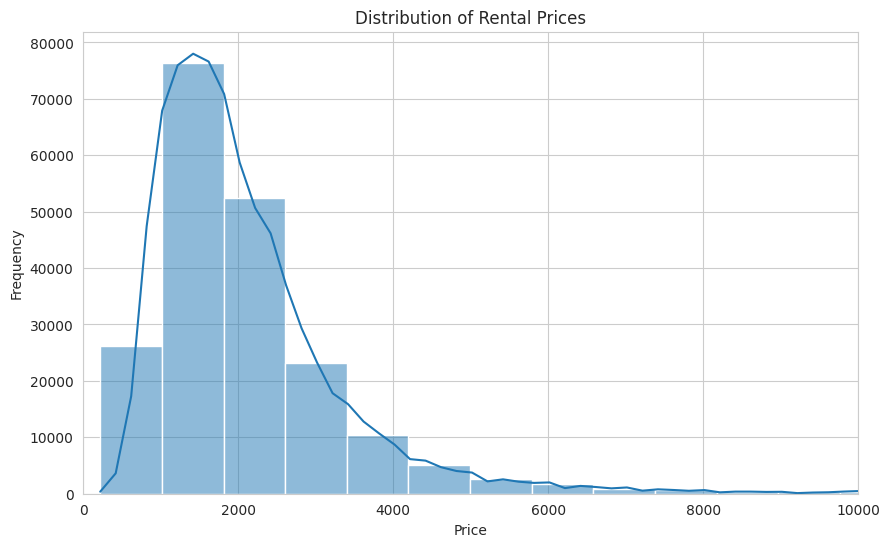

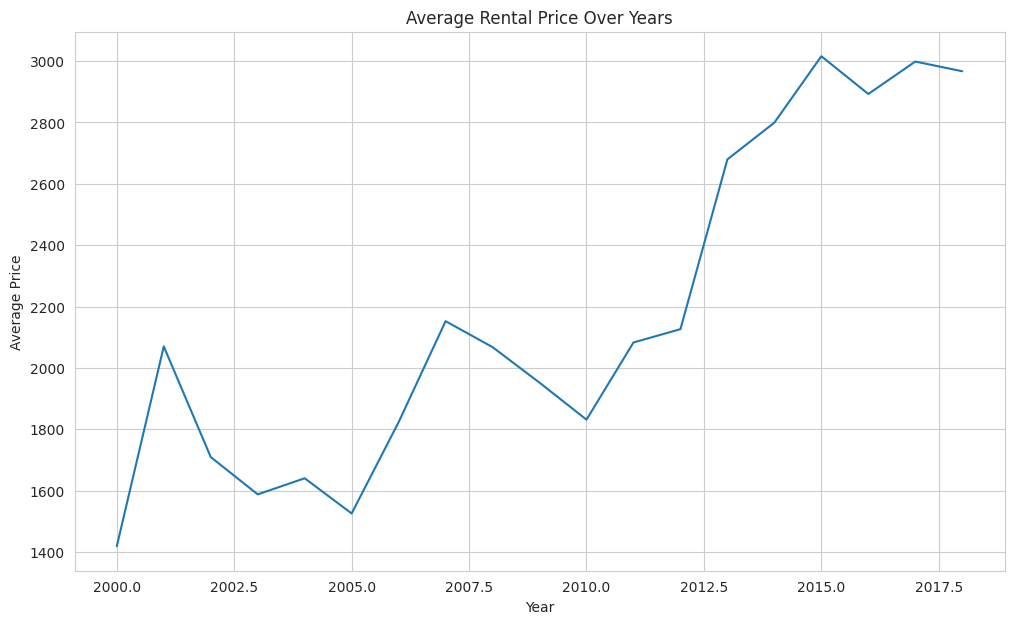

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

# Visualize the distribution of rental prices
plt.figure(figsize=(10, 6))
sns.histplot(rent['price'].dropna(), bins=50, kde=True)
plt.title('Distribution of Rental Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, 10000) # Limit x-axis to better visualize common prices
plt.show()

# Visualize average rental price over the years
# Ensure 'year' is treated as a numerical type and drop NaNs
rent_cleaned = rent.dropna(subset=['year', 'price']).copy()
rent_cleaned['year'] = rent_cleaned['year'].astype(int)

average_price_per_year = rent_cleaned.groupby('year')['price'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='year', y='price', data=average_price_per_year)
plt.title('Average Rental Price Over Years')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.show()